In [24]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as ctx
import seaborn as sns

from glob import glob

import warnings
warnings.filterwarnings('ignore')

data_dir = '/Users/jcolen/Documents/chkd_toy_problem/data'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Total Population,Population 0-19,geometry
ZCTA5CE20,,,
27818,1159,204,"POLYGON ((-77.16438 36.54633, -77.16432 36.546..."
27950,1918,394,"POLYGON ((-76.15427 36.54023, -76.15387 36.540..."
23128,707,126,"MULTIPOLYGON (((-76.45022 37.43022, -76.45002 ..."
23314,9523,2452,"POLYGON ((-76.58686 36.93857, -76.58619 36.938..."
23462,68045,16615,"POLYGON ((-76.19498 36.83293, -76.19495 36.833..."
...,...,...,...
23878,1162,277,"POLYGON ((-77.09782 36.86998, -77.09421 36.871..."
23668,739,497,"POLYGON ((-76.34185 37.02094, -76.34181 37.021..."
23667,80,8,"POLYGON ((-76.33635 37.02244, -76.33578 37.022..."


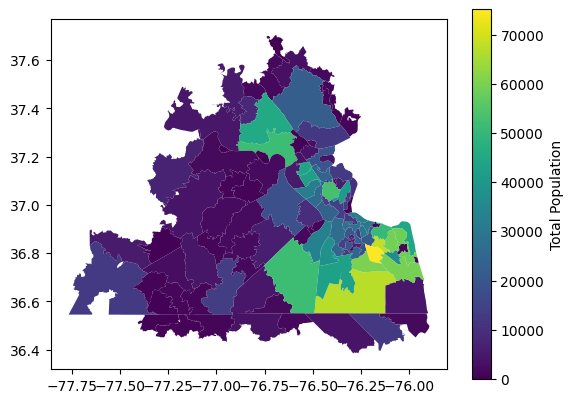

In [25]:
zcta_df = gpd.read_file(f'{data_dir}/Hampton_Roads_ZCTA_Populations/Hampton_Roads_ZCTA_Populations.shp') \
    .rename({
        'Total Popu': 'Total Population',
        'Population': 'Population 0-19',
    }, axis=1) \
    .set_index('ZCTA5CE20')
zcta_df.plot(column='Total Population', legend=True, legend_kwds=dict(label="Total Population"))
zcta_df

aian     asian       black       hisp       total  \
ZCTA5CE20 year                                                           
27818     2018   5.414479  8.623059  164.239200  12.232712  287.368470   
          2019   5.027775  6.636663  176.977690  19.105547  301.666530   
          2020  11.900134  0.000000  201.898930  25.615553  298.108760   
          2021  11.315112  0.000000  129.719680  17.780895  235.799070   
          2022  13.530777  0.000000  143.587770  16.156151  230.225220   
...                   ...       ...         ...        ...         ...   
23081     2019   0.000000  0.021254    0.012657   0.040836    0.442988   
          2020   0.000000  0.004072    0.007664   0.060356    0.462487   
          2021   0.000000  0.003551    0.002367   0.054914    0.462986   
          2022   0.000000  0.002837    0.008985   0.022226    0.400780   
          2023   0.000000  0.013292    0.000000   0.029652    0.552648   

                    white  census 0-19  
ZCTA5CE20 year                          
27818     2018  72.594124          204  
          2019  68.981079          204  
          2020  70.190895          204  
          2021  69.709320          204  
          2022  46.045101          204  
...                   ...          ...  
23081     2019   0.331704            6  
          2020   0.360936            6  
          2021   0.366885            6  
          2022   0.312349            6  
          2023   0.474429            6  

[732 rows x 7 columns]

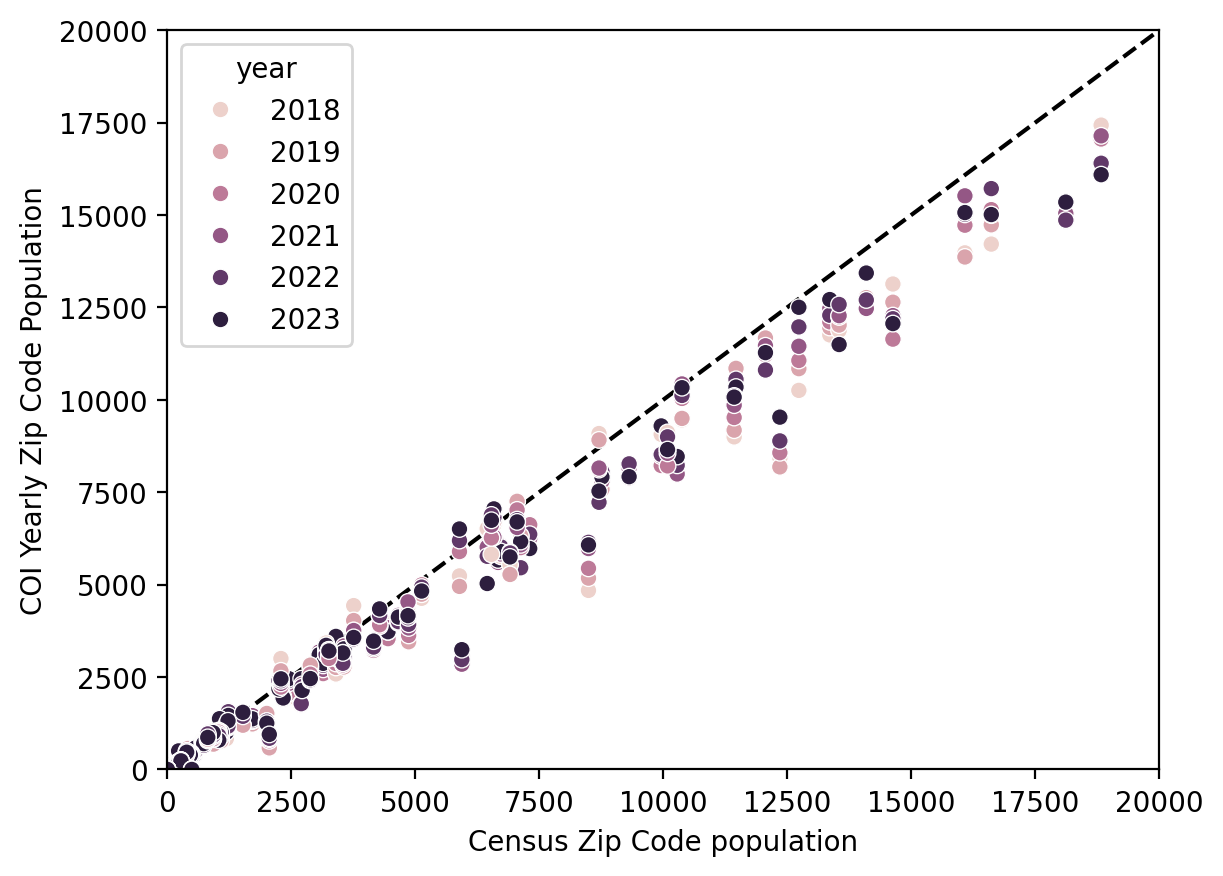

In [26]:
# COI population
coi_pop = pd.read_csv(f'{data_dir}/COI_Population_Estimates/data.csv')
coi_pop['ZCTA5CE20'] = coi_pop['zip'].astype(str).str.zfill(5)
coi_pop = coi_pop[(coi_pop['year'] >= 2018) & (coi_pop['year'] <= 2023)]
coi_pop = coi_pop.set_index(['ZCTA5CE20', 'year']) \
    .loc[zcta_df.index] \
    .drop(columns='zip')
coi_pop['census 0-19'] = coi_pop.index.get_level_values(0).map(zcta_df['Population 0-19'])

# Compare Census population with COI estimates
fig, ax = plt.subplots(1, 1, dpi=200)

sns.scatterplot(
    data=coi_pop.reset_index(),
    x='census 0-19',
    y='total',
    hue='year',
    ax=ax
)

lim = [0, 20000]
ax.plot(lim, lim, linestyle='--', color='black', zorder=-10)
ax.set(
    xlim=lim, xlabel='Census Zip Code population',
    ylim=lim, ylabel='COI Yearly Zip Code Population',
)

coi_pop

,,COI_overall_perc,COI_education_perc,COI_health_env_perc,COI_socioeco_perc,population,SVI_overall_perc
year,ZCTA5CE20,,,,,,
2018,20105,98,96,84,98,6949.766600,24.62
2019,20105,98,97,86,99,8332.879900,24.62
2020,20105,98,96,90,99,9215.917000,24.62
2021,20105,99,97,90,99,10391.062000,24.62
2022,20105,99,97,91,99,10871.511000,24.62
...,...,...,...,...,...,...,...
2019,24657,6,15,20,4,51.745651,53.58
2020,24657,3,13,18,2,55.182446,53.58
2021,24657,4,12,12,3,49.871277,53.58


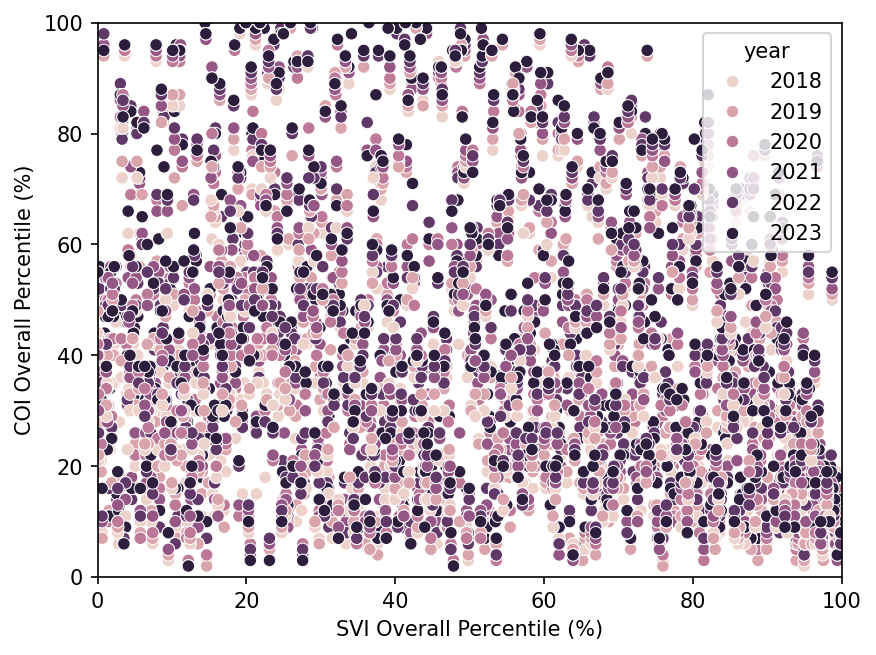

In [35]:
# Compare COI to SVI
from airquality.datamodules.data_load.load_zcta_data import load_svi_data, load_coi_data

svi_df = load_svi_data().filter(like='SVI_')
coi_df = load_coi_data()
svi_df

joint_df = coi_df.copy().assign(
    SVI_overall_perc=coi_df.index.get_level_values(1).map(svi_df['SVI_overall_perc'])*100
).dropna()

fig, ax = plt.subplots(1, 1, dpi=150)
sns.scatterplot(
    data=joint_df.reset_index(),
    x='SVI_overall_perc',
    y='COI_overall_perc',
    hue='year',
    ax=ax
)

lim = [0, 100]
ax.set(
    xlim=lim, xlabel='SVI Overall Percentile (%)',
    ylim=lim, ylabel='COI Overall Percentile (%)',
)

joint_df